# Hazard CONUS Grid - Hail M0 - Candidate Report-Side QA

**Peril:** hail - **Layer:** M0 QA / pilot-cell selection gate - **Product:** `hazard_conus_grid`

This notebook checks the four MRMS-derived pilot-cell candidates against independent report-side evidence
before the cells are locked for the selected-cell M1 pilot.

## Step back - what is this notebook for?

This notebook is a **sanity gate**, not the hazard model.

The current workflow is:

```text
1. MRMS bounded scan
     -> choose four candidate cells
     -> prove native-pixel-to-grid-cell aggregation

2. This NOAA/NRI QA notebook
     -> ask whether those four cells look sane from independent report/risk-index evidence
     -> keep or flag each candidate

3. Final selected-cell manifest
     -> lock the four cells for the pilot

4. Selected-cell M1 to M4 pilot
     -> frequency distribution
     -> hail-size distribution
     -> damage / loss
     -> EAL, VaR, PML, TVaR

5. Full CONUS fanout
     -> run the same shape for every served cell after the pilot is trusted
```

Why the MRMS window was small:

- Apr-Jun 2024 was used only to pick and inspect pilot cells quickly.
- It is not a climatology and not a final frequency estimate.
- The value from it was the **candidate set + grid aggregation proof**, not reportable risk.

Why NOAA Storm Events and NRI appear here:

- NOAA reports are an independent **ground/report sanity check**. They can tell us whether a "high" cell
  is in a report-active area or whether a "low" cell really looks quiet. They are point reports and are
  population-biased, so they do **not** become the grid truth.
- NRI is an even broader **regional sanity label**. Its frequency/risk ratings can support or question the
  candidate role. Its loss-ratio and EAL fields stay out of our loss path because their base is community
  buildings / population / agriculture, not our solar or wind grid asset.

What the `qa_*` columns mean:

- `qa_recommendation`: keep this candidate for the next pilot step, or review before lock.
- `qa_reason`: plain-English reason for that recommendation.
- `qa_status`: reminder that this is QA complete, **not final selected-cell lock**.
- `remaining_before_final_lock`: the next checks still needed before running M1.

Source-role rule:

- **MRMS daily MESH remains the grid spine.** It produced the candidate cells and daily cell evidence.
- **NOAA Storm Events is a report-side validation overlay.** It can confirm directionality and expose
  report sparsity, but it does not add grid events.
- **NRI is a broad regional sanity check only.** Its loss-ratio and EAL fields are not usable as solar/grid
  loss inputs because the exposure base is community buildings / population / agriculture, not our asset.

Plan links:

- [`docs/plans/hazard_conus_grid/hail/pilot_cell_selection.md`](../../../../../docs/plans/hazard_conus_grid/hail/pilot_cell_selection.md)
- [`docs/extra/discussion/conus_grid/hail/02_m1_build_flow.md`](../../../../../docs/extra/discussion/conus_grid/hail/02_m1_build_flow.md)
- [`docs/learning_logs/01_extending_a_short_hazard_record.md`](../../../../../docs/learning_logs/01_extending_a_short_hazard_record.md)
- [`docs/principles/notebook_work/exploratory_data_notebooks.md`](../../../../../docs/principles/notebook_work/exploratory_data_notebooks.md)

## 0 - Scope and non-goals

This notebook does:

1. Load the current MRMS-derived candidate cells.
2. Fetch/cache NOAA Storm Events hail reports around each candidate center.
3. Fetch/cache NRI hail fields at each candidate center.
4. Summarize whether report-side evidence supports, contradicts, or flags each candidate role.

It deliberately does **not**:

- lock final selected cells;
- fit `lambda_cell`;
- use NOAA reports as the grid truth;
- use NRI loss ratios or EAL in the loss path;
- perform the later Murillo & Homeyer bias-correction or SPC archive deep dive.

The carried-forward object is a QA summary, not an M1 hazard layer.

In [1]:
from __future__ import annotations

import gzip
import hashlib
import json
import math
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from dotenv import load_dotenv

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root not found")


ROOT = _repo_root()
load_dotenv(ROOT / ".env")
API_KEY = os.environ["HYDRONOS_API_KEY"]

HAIL_GRID_DIR = ROOT / "data" / "hazard_conus_grid" / "hail"
RAW_CACHE_DIR = HAIL_GRID_DIR / "report_qa_raw"
RAW_CACHE_DIR.mkdir(parents=True, exist_ok=True)

CANDIDATE_CSV = HAIL_GRID_DIR / "pilot_cell_candidates_mrms_202404_202406.csv"
DAILY_EVIDENCE_PATH = (
    HAIL_GRID_DIR / "m0_daily_cell_evidence" / "mrms_cell_day_evidence_202404_202406.parquet"
)

REPORT_WINDOW = ("1996-01-01", "2024-12-31")
MRMS_SELECTION_WINDOW = ("2024-04-01", "2024-06-30")
REPORT_RADII_MI = [25, 50]
PRIMARY_RADIUS_MI = 25
SEVERE_HAIL_IN = 1.0
WRITE_QA_ARTIFACTS = True

print("repo root:", ROOT)
print("candidate file:", CANDIDATE_CSV)
print("report window:", REPORT_WINDOW, "- NOAA magnitude reliability window used in existing hail notebooks")
print("MRMS candidate window:", MRMS_SELECTION_WINDOW)
print("raw response cache:", RAW_CACHE_DIR)

repo root: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling
candidate file: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/hail/pilot_cell_candidates_mrms_202404_202406.csv
report window: ('1996-01-01', '2024-12-31') - NOAA magnitude reliability window used in existing hail notebooks
MRMS candidate window: ('2024-04-01', '2024-06-30')
raw response cache: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/hail/report_qa_raw


## 1 - Candidate cells and MRMS evidence already produced

These are not final locked cells. They are the current candidates from the MRMS bounded-window scan.

Important base/denominator:

- `n_hail_days` is a count inside **Apr-Jun 2024 only**.
- `total_native_pixels_severe` counts native MRMS pixels above `25.4 mm`; each 0.25 degree benchmark cell
  had 625 observed native MRMS pixel centers in the daily scan.
- The daily MRMS parquet is a sparse positive-evidence table, not a full zero-filled cell x date panel.

In [2]:
candidates = pd.read_csv(CANDIDATE_CSV)
daily_evidence = pd.read_parquet(DAILY_EVIDENCE_PATH)

candidate_fields = pd.DataFrame(
    [
        ("role", "candidate purpose label", "category", "YES - pilot design"),
        ("cell_id", "benchmark grid join key", "integer", "YES - durable grid key"),
        ("lat_center", "candidate cell center latitude", "degrees", "YES - report query center"),
        ("lon_center", "candidate cell center longitude", "degrees", "YES - report query center"),
        ("selection_window", "MRMS selection window", "date range", "YES - scope caveat"),
        ("n_hail_days", "MRMS severe-hail days in selection window", "days", "YES - candidate evidence"),
        (
            "total_native_pixels_severe",
            "native MRMS pixels above threshold across selection window",
            "pixel count, denominator 625 per cell-day",
            "YES - area/coverage proxy",
        ),
        ("mesh_max_mm", "maximum raw MESH in candidate cell during selection window", "mm", "YES - size proxy"),
    ],
    columns=["field", "what it is", "units / reference base", "how we use it"],
)

candidate_fields

,field,what it is,units / reference base,how we use it
0,role,candidate purpose label,category,YES - pilot design
1,cell_id,benchmark grid join key,integer,YES - durable grid key
2,lat_center,candidate cell center latitude,degrees,YES - report query center
3,lon_center,candidate cell center longitude,degrees,YES - report query center
4,selection_window,MRMS selection window,date range,YES - scope caveat
5,n_hail_days,MRMS severe-hail days in selection window,days,YES - candidate evidence
6,total_native_pixels_severe,native MRMS pixels above threshold across sele...,"pixel count, denominator 625 per cell-day",YES - area/coverage proxy
7,mesh_max_mm,maximum raw MESH in candidate cell during sele...,mm,YES - size proxy


In [3]:
print("candidate cells:")
display(
    candidates[
        [
            "role",
            "cell_id",
            "lat_center",
            "lon_center",
            "state_abbr",
            "iso_rto",
            "n_hail_days",
            "total_native_pixels_severe",
            "mesh_max_mm",
        ]
    ]
)

print("daily MRMS evidence rows:", len(daily_evidence))
print("daily MRMS evidence source timestamps:", daily_evidence["source_timestamp"].min(), "to", daily_evidence["source_timestamp"].max())

candidate cells:


,role,cell_id,lat_center,lon_center,state_abbr,iso_rto,n_hail_days,total_native_pixels_severe,mesh_max_mm
0,high_hail,329354,33.00,-101.50,TX,ERCOT,12,636,105.800003
1,medium_hail,261700,44.75,-95.00,MN,MISO,2,40,37.299999
2,low_hail,247197,47.25,-120.75,WA,WEIM,0,0,NaN
3,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,2,16,33.299999


daily MRMS evidence rows: 14449
daily MRMS evidence source timestamps: 2024-04-01 23:30:00+00:00 to 2024-06-30 23:30:00+00:00


**Takeaway.** The report-side QA starts from MRMS-derived candidates. It does not re-select from legacy
outputs and does not treat old delivery artifacts as evidence.

## 2 - Source roles and fields

NOAA Storm Events is long, point-based, and biased toward places with people/roads/reporting. That makes it
valuable for sanity checks, but dangerous as the grid event spine.

NRI is even further downstream: frequency x exposure x historic loss ratio x social/resilience factors. It
can provide a rough regional label, but its dollar/risk fields are not an asset-specific hail hazard layer.

In [4]:
source_roles = pd.DataFrame(
    [
        (
            "MRMS daily MESH",
            "gridded radar hail-size estimate",
            "primary grid spine",
            "cell evidence and candidate selection",
            "raw MESH over-predicts; short bounded window here",
        ),
        (
            "NOAA Storm Events via Hydronos",
            "point reports with reported hail size",
            "validation overlay",
            "directional report-side QA and size sanity",
            "population/road/reporting bias; no footprint",
        ),
        (
            "FEMA NRI via Hydronos",
            "county/tract risk-index fields",
            "broad regional sanity only",
            "hail_afreq and rating context",
            "loss ratio/EAL base is community exposure, not our grid asset",
        ),
    ],
    columns=["source", "what it is", "role", "used for", "main caveat"],
)
source_roles

,source,what it is,role,used for,main caveat
0,MRMS daily MESH,gridded radar hail-size estimate,primary grid spine,cell evidence and candidate selection,raw MESH over-predicts; short bounded window here
1,NOAA Storm Events via Hydronos,point reports with reported hail size,validation overlay,directional report-side QA and size sanity,population/road/reporting bias; no footprint
2,FEMA NRI via Hydronos,county/tract risk-index fields,broad regional sanity only,hail_afreq and rating context,"loss ratio/EAL base is community exposure, not..."


In [5]:
NOAA_DESC = {
    "EVENT_ID": ("Individual event id - one hail report at a place/time", "id", "YES - dedup key"),
    "EPISODE_ID": ("Parent storm episode id; many reports can share one episode", "id", "context - declustering later"),
    "BEGIN_DATE_TIME": ("Event start timestamp", "UTC datetime", "YES - report date/window"),
    "END_DATE_TIME": ("Event end timestamp", "UTC datetime", "context"),
    "EVENT_TYPE": ("NOAA event type", "string", "YES - filter to Hail"),
    "MAGNITUDE": ("Reported hail diameter", "inches", "YES - report-side size sanity"),
    "MAGNITUDE_TYPE": ("Magnitude type/unit code", "string/null", "context"),
    "BEGIN_LAT": ("Report latitude", "degrees", "YES - distance and map"),
    "BEGIN_LON": ("Report longitude", "degrees", "YES - distance and map"),
    "END_LAT": ("Report end latitude", "degrees", "minor"),
    "END_LON": ("Report end longitude", "degrees", "minor"),
    "CZ_TIMEZONE": ("Timestamp timezone label", "string", "context"),
    "STATE": ("State name", "string", "context"),
    "STATE_FIPS": ("State FIPS code", "code", "context"),
    "CZ_NAME": ("County / forecast-zone name", "string", "context"),
    "CZ_FIPS": ("County / forecast-zone FIPS", "code", "context"),
    "CZ_TYPE": ("County/zone basis of record", "C/Z", "context"),
    "INJURIES_DIRECT": ("Direct injuries", "count", "NO - not a grid asset loss input"),
    "INJURIES_INDIRECT": ("Indirect injuries", "count", "NO"),
    "DEATHS_DIRECT": ("Direct deaths", "count", "NO"),
    "DEATHS_INDIRECT": ("Indirect deaths", "count", "NO"),
    "DAMAGE_PROPERTY": ("NOAA property damage estimate", "$ string", "NO - not PV/grid asset loss"),
    "DAMAGE_CROPS": ("NOAA crop damage estimate", "$ string", "NO"),
    "FLOOD_CAUSE": ("Flood cause field", "string/null", "NO - not hail"),
    "CATEGORY": ("Hazard category field", "string/null", "NO - not hail"),
    "TOR_F_SCALE": ("Tornado scale field", "string/null", "NO - not hail"),
    "TOR_LENGTH": ("Tornado path length", "miles/null", "NO - not hail"),
    "TOR_WIDTH": ("Tornado path width", "yards/null", "NO - not hail"),
    "EPISODE_NARRATIVE": ("Episode narrative", "free text", "spot-check only"),
    "EVENT_NARRATIVE": ("Event narrative", "free text", "spot-check only"),
    "SOURCE": ("Reporter/source label", "string", "provenance context"),
    "FILENAME": ("NCEI source file name", "string", "provenance"),
}

NRI_DESC = {
    "hail_afreq": ("Annualized hail frequency at NRI geography", "events/year", "regional sanity only"),
    "hail_evnts": ("Historic recorded hail occurrence count/model count", "count", "context"),
    "hail_riskr": ("Composite hail risk rating", "ordinal", "regional label only"),
    "hail_ealr": ("Expected annual loss rating", "ordinal", "context only"),
    "hail_hlrr": ("Historic loss-ratio rating", "ordinal", "context only"),
    "hail_expb": ("Building exposure in NRI geography", "$ community building value", "NO - not our asset value"),
    "hail_hlrb": ("Historic loss ratio for buildings", "$ loss / $ community building exposure", "NO - not solar/grid loss"),
}

## 3 - Hydronos fetch with raw response cache

The cache stores the exact JSON responses as `.json.gz` files under `data/`. Those files are ignored by git
because they are raw API/cache artifacts. The committed outputs are only small QA summaries.

In [6]:
class HydronosHazard:
    BASE = "https://api.hydronoslabs.com/hazard"

    def __init__(self, api_key: str, cache_dir: Path):
        self.headers = {"accept": "application/json", "x-api-key": api_key}
        self.cache_dir = cache_dir

    @staticmethod
    def _safe_name(value: str) -> str:
        return re.sub(r"[^A-Za-z0-9_.-]+", "_", value)

    def _cache_path(self, path: str, params: dict, label: str) -> Path:
        payload = json.dumps({"path": path, "params": params}, sort_keys=True)
        digest = hashlib.sha1(payload.encode("utf-8")).hexdigest()[:12]
        return self.cache_dir / f"{self._safe_name(label)}_{digest}.json.gz"

    @staticmethod
    def _records(payload: dict) -> list[dict]:
        data = payload.get("data")
        if isinstance(data, dict):
            return [data]
        return data or []

    def get(self, path: str, params: dict, label: str) -> dict:
        cache_path = self._cache_path(path, params, label)
        if cache_path.exists():
            with gzip.open(cache_path, "rt", encoding="utf-8") as f:
                return json.load(f)

        response = requests.get(f"{self.BASE}{path}", params=params, headers=self.headers, timeout=180)
        response.raise_for_status()
        payload = response.json()
        cache_body = {
            "path": path,
            "params": params,
            "status_code": response.status_code,
            "url_without_key": response.url,
            "payload": payload,
        }
        with gzip.open(cache_path, "wt", encoding="utf-8") as f:
            json.dump(cache_body, f)
        return cache_body

    def noaa_storm(self, row: pd.Series, radius_mi: int) -> pd.DataFrame:
        params = {
            "lat": float(row["lat_center"]),
            "lon": float(row["lon_center"]),
            "startDate": REPORT_WINDOW[0],
            "endDate": REPORT_WINDOW[1],
            "incidentType": "Hail",
            "distance": int(radius_mi),
        }
        label = f"noaa_{row['role']}_{row['cell_id']}_{radius_mi}mi_{REPORT_WINDOW[0]}_{REPORT_WINDOW[1]}"
        body = self.get("/hist/noaa_storm", params, label)
        records = self._records(body["payload"])
        df = pd.DataFrame(records)
        if df.empty:
            df = pd.DataFrame(columns=list(NOAA_DESC))
        df.insert(0, "radius_mi", int(radius_mi))
        df.insert(0, "role", row["role"])
        df.insert(1, "cell_id", int(row["cell_id"]))
        df.insert(2, "candidate_lat", float(row["lat_center"]))
        df.insert(3, "candidate_lon", float(row["lon_center"]))
        return df

    def nri_risk(self, row: pd.Series) -> dict:
        params = {"lat": float(row["lat_center"]), "lon": float(row["lon_center"])}
        label = f"nri_{row['role']}_{row['cell_id']}"
        body = self.get("/risk", params, label)
        records = self._records(body["payload"])
        return records[0] if records else {}


haz = HydronosHazard(API_KEY, RAW_CACHE_DIR)

report_frames = []
for _, row in candidates.iterrows():
    for radius in REPORT_RADII_MI:
        report_frames.append(haz.noaa_storm(row, radius))

reports_raw = pd.concat(report_frames, ignore_index=True)
print("raw NOAA rows:", len(reports_raw))
print("raw cache files:", len(list(RAW_CACHE_DIR.glob("*.json.gz"))))
reports_raw.head()

raw NOAA rows: 3893
raw cache files: 8


,role,cell_id,candidate_lat,candidate_lon,radius_mi,BEGIN_DATE_TIME,END_DATE_TIME,CZ_TIMEZONE,EPISODE_ID,EVENT_ID,...,DAMAGE_CROPS,FLOOD_CAUSE,CATEGORY,TOR_F_SCALE,TOR_LENGTH,TOR_WIDTH,EPISODE_NARRATIVE,EVENT_NARRATIVE,SOURCE,FILENAME
0,high_hail,329354,33.0,-101.5,25,2013-05-07T19:00:00.000Z,2013-05-07T19:05:00.000Z,CST-6,72981,440673,...,NaN,None,None,None,None,None,A weak upper level ridge was over the area wit...,A thunderstorm moved over Borden County and pr...,Law Enforcement,StormEvents_details-ftp_v1.0_d2013_c20260316.csv
1,high_hail,329354,33.0,-101.5,25,2013-05-23T18:03:00.000Z,2013-05-23T18:03:00.000Z,CST-6,73215,443608,...,0.00K,None,None,None,None,None,Driven southwest by outflow from a complex of ...,A resident reported hail slightly larger than ...,Public,StormEvents_details-ftp_v1.0_d2013_c20260316.csv
2,high_hail,329354,33.0,-101.5,25,2013-05-27T17:26:00.000Z,2013-05-27T17:30:00.000Z,CST-6,73332,443307,...,0.00K,None,None,None,None,None,The dryline mixed east of the Caprock Escarpme...,Law enforcement personnel in Post estimated go...,Law Enforcement,StormEvents_details-ftp_v1.0_d2013_c20260316.csv
3,high_hail,329354,33.0,-101.5,25,2013-03-29T19:38:00.000Z,2013-03-29T19:38:00.000Z,CST-6,71760,432181,...,0.00K,None,None,None,None,None,A potent upper level shortwave trough approach...,Law enforcement officials reported quarter siz...,Law Enforcement,StormEvents_details-ftp_v1.0_d2013_c20260316.csv
4,high_hail,329354,33.0,-101.5,25,2023-04-09T19:38:00.000Z,2023-04-09T19:38:00.000Z,CST-6,177684,1081346,...,0.00K,None,None,None,None,None,Easter Sunday brought severe thunderstorms to ...,An NWS cooperative weather observer located in...,COOP Observer,StormEvents_details-ftp_v1.0_d2023_c20260316.csv


## 4 - NOAA field completeness and cleaning

The table below documents the returned NOAA fields before we use them. Unknown returned columns would show
as undocumented instead of silently entering the QA.

In [7]:
raw_noaa_cols = [
    c
    for c in reports_raw.columns
    if c not in {"role", "cell_id", "candidate_lat", "candidate_lon", "radius_mi"}
]
noaa_field_dictionary = pd.DataFrame(
    [
        (
            col,
            *NOAA_DESC.get(col, ("UNDOCUMENTED - add field meaning before use", "", "?")),
        )
        for col in raw_noaa_cols
    ],
    columns=["field", "what it is", "units / reference base", "how we use it"],
)
print("returned NOAA columns:", len(raw_noaa_cols))
print("undocumented:", [c for c in raw_noaa_cols if c not in NOAA_DESC] or "none")
noaa_field_dictionary

returned NOAA columns: 32
undocumented: none


,field,what it is,units / reference base,how we use it
0,BEGIN_DATE_TIME,Event start timestamp,UTC datetime,YES - report date/window
1,END_DATE_TIME,Event end timestamp,UTC datetime,context
2,CZ_TIMEZONE,Timestamp timezone label,string,context
3,EPISODE_ID,Parent storm episode id; many reports can shar...,id,context - declustering later
4,EVENT_ID,Individual event id - one hail report at a pla...,id,YES - dedup key
5,STATE_FIPS,State FIPS code,code,context
6,CZ_FIPS,County / forecast-zone FIPS,code,context
7,STATE,State name,string,context
8,CZ_NAME,County / forecast-zone name,string,context
9,CZ_TYPE,County/zone basis of record,C/Z,context


In [8]:
def haversine_mi(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    radius_mi = 3958.8
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dphi, dlambda = math.radians(lat2 - lat1), math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dlambda / 2) ** 2
    return 2 * radius_mi * math.asin(math.sqrt(a))


def clean_noaa_reports(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["begin_dt"] = pd.to_datetime(out["BEGIN_DATE_TIME"], errors="coerce", utc=True)
    out["report_date"] = out["begin_dt"].dt.date
    out["year"] = out["begin_dt"].dt.year
    out["magnitude_in"] = pd.to_numeric(out["MAGNITUDE"], errors="coerce")
    out["BEGIN_LAT"] = pd.to_numeric(out["BEGIN_LAT"], errors="coerce")
    out["BEGIN_LON"] = pd.to_numeric(out["BEGIN_LON"], errors="coerce")
    out["distance_mi_calc"] = [
        haversine_mi(clat, clon, lat, lon)
        if pd.notna(lat) and pd.notna(lon)
        else np.nan
        for clat, clon, lat, lon in zip(
            out["candidate_lat"],
            out["candidate_lon"],
            out["BEGIN_LAT"],
            out["BEGIN_LON"],
        )
    ]
    out["event_type_clean"] = out["EVENT_TYPE"].astype(str).str.strip()
    out = out[out["event_type_clean"].eq("Hail")].copy()
    out = out.drop_duplicates(subset=["role", "cell_id", "radius_mi", "EVENT_ID"])
    out["severe_report_flag"] = out["magnitude_in"] >= SEVERE_HAIL_IN
    start, end = [pd.Timestamp(x, tz="UTC") for x in MRMS_SELECTION_WINDOW]
    out["in_mrms_selection_window"] = out["begin_dt"].between(start, end + pd.Timedelta(days=1))
    return out


reports = clean_noaa_reports(reports_raw)

quality = pd.DataFrame(
    [
        ("raw rows", len(reports_raw)),
        ("after EVENT_TYPE == Hail and EVENT_ID dedup within role/radius", len(reports)),
        ("missing magnitude", int(reports["magnitude_in"].isna().sum())),
        ("missing date", int(reports["begin_dt"].isna().sum())),
        ("missing coords", int(reports["BEGIN_LAT"].isna().sum() + reports["BEGIN_LON"].isna().sum())),
    ],
    columns=["check", "n"],
)
quality

,check,n
0,raw rows,3893
1,after EVENT_TYPE == Hail and EVENT_ID dedup wi...,3893
2,missing magnitude,0
3,missing date,0
4,missing coords,0


**Takeaway.** NOAA reports are usable as a report-side check for these candidates. Their counts are still
report counts, not benchmark-cell event rates.

## 5 - Report-side summary by candidate and radius

We use 25 miles as the primary cell-neighborhood check and 50 miles as wider context. Neither radius is
the cell itself. The radius exists only to answer: "does the local report environment broadly agree with
the candidate role?"

In [9]:
def quantile_or_nan(series: pd.Series, q: float) -> float:
    clean = series.dropna()
    return float(clean.quantile(q)) if len(clean) else np.nan


summary_rows = []
for _, cand in candidates.iterrows():
    for radius in REPORT_RADII_MI:
        subset = reports[(reports["cell_id"] == cand["cell_id"]) & (reports["radius_mi"] == radius)]
        summary_rows.append(
            {
                "role": cand["role"],
                "cell_id": int(cand["cell_id"]),
                "radius_mi": int(radius),
                "noaa_reports": int(len(subset)),
                "noaa_report_days": int(subset["report_date"].nunique()),
                "noaa_reports_per_year": round(len(subset) / (2024 - 1996 + 1), 3),
                "noaa_severe_reports_ge_1in": int(subset["severe_report_flag"].sum()),
                "noaa_mrms_window_reports": int(subset["in_mrms_selection_window"].sum()),
                "noaa_mrms_window_report_days": int(
                    subset.loc[subset["in_mrms_selection_window"], "report_date"].nunique()
                ),
                "noaa_max_size_in": round(float(subset["magnitude_in"].max()), 3) if len(subset) else np.nan,
                "noaa_p95_size_in": round(quantile_or_nan(subset["magnitude_in"], 0.95), 3),
            }
        )

report_summary = pd.DataFrame(summary_rows)
report_summary

,role,cell_id,radius_mi,noaa_reports,noaa_report_days,noaa_reports_per_year,noaa_severe_reports_ge_1in,noaa_mrms_window_reports,noaa_mrms_window_report_days,noaa_max_size_in,noaa_p95_size_in
0,high_hail,329354,25,310,137,10.690,227,8,5,5.00,2.75
1,high_hail,329354,50,1376,399,47.448,1032,39,14,5.00,2.75
2,medium_hail,261700,25,285,127,9.828,152,3,2,4.25,2.50
3,medium_hail,261700,50,1449,338,49.966,771,7,4,4.50,2.00
4,low_hail,247197,25,9,7,0.310,5,0,0,1.50,1.40
5,low_hail,247197,50,29,17,1.000,13,0,0,1.50,1.25
6,hayhurst_reference,336544,25,65,41,2.241,48,1,1,4.00,2.50
7,hayhurst_reference,336544,50,370,180,12.759,266,4,2,4.25,2.50


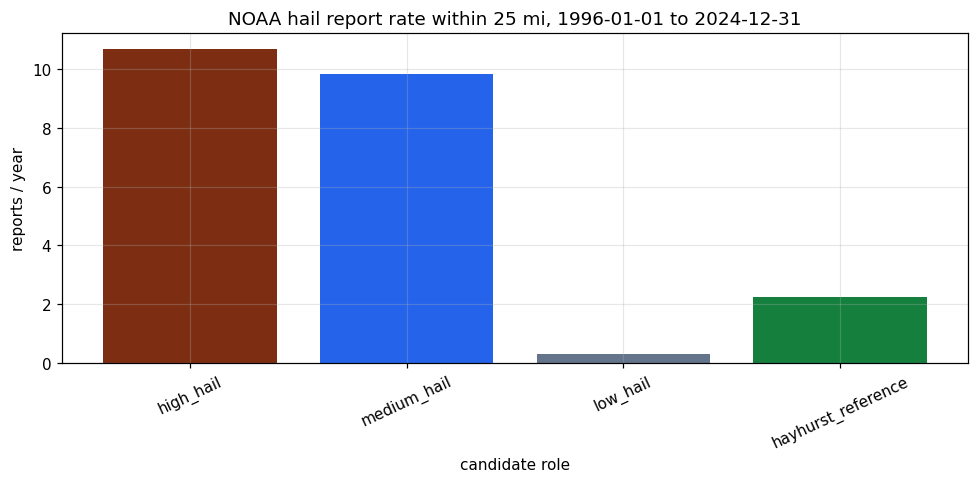

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = report_summary[report_summary["radius_mi"].eq(PRIMARY_RADIUS_MI)]
ax.bar(plot_df["role"], plot_df["noaa_reports_per_year"], color=["#7c2d12", "#2563eb", "#64748b", "#15803d"])
ax.set(
    title=f"NOAA hail report rate within {PRIMARY_RADIUS_MI} mi, {REPORT_WINDOW[0]} to {REPORT_WINDOW[1]}",
    ylabel="reports / year",
    xlabel="candidate role",
)
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

**Takeaway.** Report density is much lower around the WA low-hail candidate than around the TX/MN active
hail candidates. The TX high and MN medium candidates both sit in report-active areas, which supports
"nonzero hail" but does not by itself distinguish high vs medium grid-cell behavior.

## 6 - NRI hail fields at candidate centers

NRI fields are documented here because their bases are easy to misuse. We use only `hail_afreq` and ratings
as a broad regional sanity check. We do not use `hail_hlrb`, `hail_ealb`, or `hail_ealt` in the grid loss
path.

In [11]:
nri_rows = []
for _, cand in candidates.iterrows():
    risk = haz.nri_risk(cand)
    row = {
        "role": cand["role"],
        "cell_id": int(cand["cell_id"]),
        "lat_center": float(cand["lat_center"]),
        "lon_center": float(cand["lon_center"]),
    }
    for field in NRI_DESC:
        row[field] = risk.get(field)
    nri_rows.append(row)

nri_summary = pd.DataFrame(nri_rows)

nri_field_dictionary = pd.DataFrame(
    [(field, *desc) for field, desc in NRI_DESC.items()],
    columns=["field", "what it is", "units / reference base", "how we use it"],
)
nri_field_dictionary

,field,what it is,units / reference base,how we use it
0,hail_afreq,Annualized hail frequency at NRI geography,events/year,regional sanity only
1,hail_evnts,Historic recorded hail occurrence count/model ...,count,context
2,hail_riskr,Composite hail risk rating,ordinal,regional label only
3,hail_ealr,Expected annual loss rating,ordinal,context only
4,hail_hlrr,Historic loss-ratio rating,ordinal,context only
5,hail_expb,Building exposure in NRI geography,$ community building value,NO - not our asset value
6,hail_hlrb,Historic loss ratio for buildings,$ loss / $ community building exposure,NO - not solar/grid loss


In [12]:
nri_summary

,role,cell_id,lat_center,lon_center,hail_afreq,hail_evnts,hail_riskr,hail_ealr,hail_hlrr,hail_expb,hail_hlrb
0,high_hail,329354,33.00,-101.50,4.900707,186.216836,Very High,Very High,Relatively High,630760132,0.000050
1,medium_hail,261700,44.75,-95.00,4.564749,173.460480,Relatively Moderate,Relatively Moderate,Relatively Moderate,1622344906,0.000006
2,low_hail,247197,47.25,-120.75,0.066496,2.522797,Very Low,Very Low,Very Low,1952378234,0.000002
3,hayhurst_reference,336544,31.75,-104.00,1.561249,59.317752,Relatively High,Relatively Moderate,Relatively Low,1388117472,0.000028


**Takeaway.** NRI agrees directionally with the intended spread: TX high is very high, WA low is very low,
Hayhurst is elevated, and the MN body case is not a quiet/low-hail cell. This remains a sanity label, not
a modeling input.

## 7 - Candidate QA synthesis

The QA decision here is intentionally conservative:

- "keep" meant the candidate was suitable for the V0 selected-cell M1 pilot unless the later SPC/map review
  found a problem.
- "review" means the role label or candidate choice needs more attention before final lock.
- No row below is a final selected-cell lock.

In [13]:
primary_report = report_summary[report_summary["radius_mi"].eq(PRIMARY_RADIUS_MI)].drop(columns=["radius_mi"])
qa = (
    candidates[
        [
            "role",
            "cell_id",
            "lat_center",
            "lon_center",
            "state_abbr",
            "iso_rto",
            "n_hail_days",
            "total_native_pixels_severe",
            "mesh_max_mm",
        ]
    ]
    .merge(primary_report, on=["role", "cell_id"], how="left")
    .merge(nri_summary[["role", "cell_id", "hail_afreq", "hail_riskr", "hail_ealr", "hail_hlrr"]], on=["role", "cell_id"], how="left")
)


def qa_recommendation(row: pd.Series) -> tuple[str, str]:
    role = row["role"]
    reports_per_year = float(row["noaa_reports_per_year"])
    hail_afreq = float(row["hail_afreq"]) if pd.notna(row["hail_afreq"]) else np.nan

    if role == "high_hail":
        if reports_per_year >= 5 and hail_afreq >= 1:
            return (
                "keep_candidate_pending_spc_map_review",
                "MRMS high-evidence candidate is also report-active and NRI-high; no contradiction found.",
            )
        return (
            "review_before_lock",
            "High role needs review because report/NRI evidence is weaker than expected.",
        )

    if role == "medium_hail":
        if reports_per_year >= 1 and row["n_hail_days"] > 0:
            return (
                "keep_body_case_pending_spc_map_review",
                "MRMS bounded-window evidence is body-case; report/NRI evidence confirms hail-active, not low.",
            )
        return (
            "review_before_lock",
            "Medium role needs review because either MRMS or report evidence is too sparse.",
        )

    if role == "low_hail":
        if reports_per_year < 1 and hail_afreq < 0.5 and row["n_hail_days"] == 0:
            return (
                "keep_low_control_pending_spc_map_review",
                "MRMS has zero severe days in the window and report/NRI evidence is low; suitable quiet control.",
            )
        return (
            "review_before_lock",
            "Low role may not be low enough or could have report/grid mismatch; inspect before lock.",
        )

    if role == "hayhurst_reference":
        return (
            "keep_reference_pending_spc_map_review",
            "Reference cell maps to the completed Hayhurst work and has moderate report/NRI hail context.",
        )

    return ("review_before_lock", "Unknown candidate role.")


qa[["qa_recommendation", "qa_reason"]] = qa.apply(
    lambda row: pd.Series(qa_recommendation(row)), axis=1
)
qa["qa_status"] = "candidate_report_qa_complete_not_final_lock"
qa["remaining_before_final_lock"] = "SPC/map review and broad climatology check"
qa

,role,cell_id,lat_center,lon_center,state_abbr,iso_rto,n_hail_days,total_native_pixels_severe,mesh_max_mm,noaa_reports,...,noaa_max_size_in,noaa_p95_size_in,hail_afreq,hail_riskr,hail_ealr,hail_hlrr,qa_recommendation,qa_reason,qa_status,remaining_before_final_lock
0,high_hail,329354,33.00,-101.50,TX,ERCOT,12,636,105.800003,310,...,5.00,2.75,4.900707,Very High,Very High,Relatively High,keep_candidate_pending_spc_map_review,MRMS high-evidence candidate is also report-ac...,candidate_report_qa_complete_not_final_lock,SPC/map review and broad climatology check
1,medium_hail,261700,44.75,-95.00,MN,MISO,2,40,37.299999,285,...,4.25,2.50,4.564749,Relatively Moderate,Relatively Moderate,Relatively Moderate,keep_body_case_pending_spc_map_review,MRMS bounded-window evidence is body-case; rep...,candidate_report_qa_complete_not_final_lock,SPC/map review and broad climatology check
2,low_hail,247197,47.25,-120.75,WA,WEIM,0,0,NaN,9,...,1.50,1.40,0.066496,Very Low,Very Low,Very Low,keep_low_control_pending_spc_map_review,MRMS has zero severe days in the window and re...,candidate_report_qa_complete_not_final_lock,SPC/map review and broad climatology check
3,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,2,16,33.299999,65,...,4.00,2.50,1.561249,Relatively High,Relatively Moderate,Relatively Low,keep_reference_pending_spc_map_review,Reference cell maps to the completed Hayhurst ...,candidate_report_qa_complete_not_final_lock,SPC/map review and broad climatology check


**Takeaway.** The report-side check supports keeping the four current candidates for the next M1 pilot
planning step, but it still does not lock them. The medium candidate is a body-case in the MRMS bounded
window, not a report-low location.

## 8 - Temporal overlap with the MRMS selection window

This is a narrow check: do NOAA reports appear during the same Apr-Jun 2024 window used by the MRMS
candidate scan? Zero reports here does not disprove MRMS because reports are sparse and population-biased.

In [14]:
window_rows = []
for _, cand in candidates.iterrows():
    subset = reports[
        (reports["cell_id"] == cand["cell_id"])
        & (reports["radius_mi"] == PRIMARY_RADIUS_MI)
        & (reports["in_mrms_selection_window"])
    ].copy()
    window_rows.append(
        {
            "role": cand["role"],
            "cell_id": int(cand["cell_id"]),
            "mrms_hail_days": int(cand["n_hail_days"]),
            "noaa_reports_in_mrms_window": int(len(subset)),
            "noaa_report_days_in_mrms_window": int(subset["report_date"].nunique()),
            "noaa_max_size_in_window": round(float(subset["magnitude_in"].max()), 3) if len(subset) else np.nan,
        }
    )
window_compare = pd.DataFrame(window_rows)
window_compare

,role,cell_id,mrms_hail_days,noaa_reports_in_mrms_window,noaa_report_days_in_mrms_window,noaa_max_size_in_window
0,high_hail,329354,12,8,5,2.75
1,medium_hail,261700,2,3,2,1.25
2,low_hail,247197,0,0,0,NaN
3,hayhurst_reference,336544,2,1,1,1.00


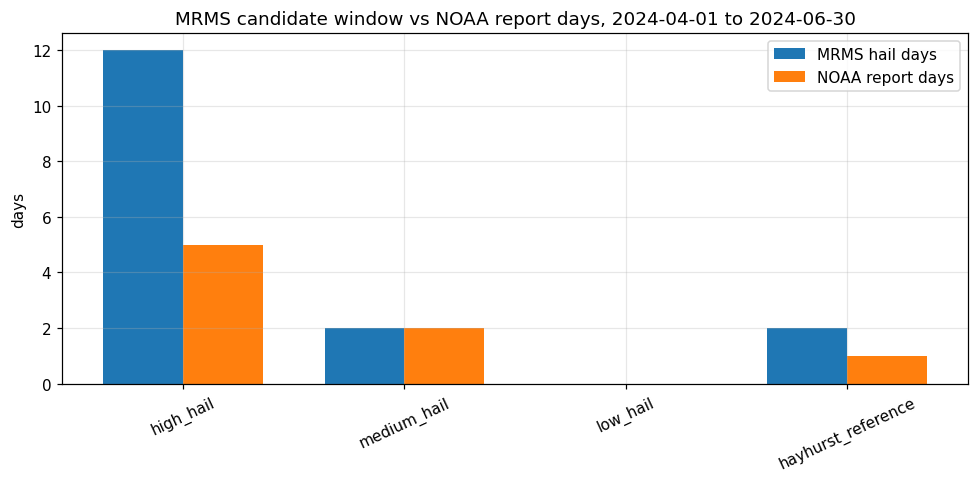

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(window_compare))
width = 0.36
ax.bar(x - width / 2, window_compare["mrms_hail_days"], width, label="MRMS hail days")
ax.bar(x + width / 2, window_compare["noaa_report_days_in_mrms_window"], width, label="NOAA report days")
ax.set(
    title=f"MRMS candidate window vs NOAA report days, {MRMS_SELECTION_WINDOW[0]} to {MRMS_SELECTION_WINDOW[1]}",
    ylabel="days",
    xticks=x,
    xticklabels=window_compare["role"],
)
ax.tick_params(axis="x", rotation=25)
ax.legend()
plt.tight_layout()
plt.show()

**Takeaway.** Any mismatch in this short window is expected and should be documented, not "fixed" by adding
NOAA reports as events. The M1 pilot should continue to use MRMS as the spine and carry NOAA as QA.

## 9 - Write QA artifacts

These outputs are small summaries. They do not lock final cells and they do not contain the M1 frequency or
size-distribution layer.

In [16]:
qa_csv = HAIL_GRID_DIR / "pilot_cell_report_qa_hydronos_1996_2024.csv"
qa_json = HAIL_GRID_DIR / "pilot_cell_report_qa_hydronos_1996_2024.json"

if WRITE_QA_ARTIFACTS:
    qa.to_csv(qa_csv, index=False)
    qa_json.write_text(
        json.dumps(
            {
                "artifact": qa_csv.name,
                "status": "candidate_report_qa_complete_not_final_lock",
                "source": {
                    "storm_events": "Hydronos / NOAA Storm Events",
                    "nri": "Hydronos / FEMA NRI",
                },
                "report_window": {"start": REPORT_WINDOW[0], "end": REPORT_WINDOW[1]},
                "mrms_selection_window": {"start": MRMS_SELECTION_WINDOW[0], "end": MRMS_SELECTION_WINDOW[1]},
                "primary_radius_mi": PRIMARY_RADIUS_MI,
                "context_radii_mi": REPORT_RADII_MI,
                "severe_hail_report_threshold_in": SEVERE_HAIL_IN,
                "raw_cache_dir": str(RAW_CACHE_DIR.relative_to(ROOT)),
                "source_notebook": "Notebooks/hazard_conus_grid/hail/m0_input_data/03_storm_events_anchor/01_candidate_report_qa.ipynb",
                "candidate_recommendations": qa[
                    ["role", "cell_id", "qa_recommendation", "qa_reason", "remaining_before_final_lock"]
                ].to_dict(orient="records"),
                "caveats": [
                    "NOAA Storm Events are point reports and are population/road/reporting biased.",
                    "NRI hail loss-ratio and EAL fields are not asset-specific hazard inputs.",
                    "This QA summary does not lock final selected cells.",
                    "SPC/map review and broader climatology checks remain before final lock.",
                ],
            },
            indent=2,
        )
    )
    print("wrote candidate QA summary:", qa_csv)
    print("wrote candidate QA metadata:", qa_json)
else:
    print("WRITE_QA_ARTIFACTS is False; no files written")

wrote candidate QA summary: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/hail/pilot_cell_report_qa_hydronos_1996_2024.csv
wrote candidate QA metadata: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/hail/pilot_cell_report_qa_hydronos_1996_2024.json


## 10 - Recap and next step

What this notebook established:

- NOAA Storm Events can be fetched and cached for the candidate-cell neighborhoods.
- Report-side evidence directionally supports the candidate spread: active TX/MN, quiet WA, reference TX.
- NRI agrees directionally as a regional sanity label, while its loss-ratio/EAL fields remain out of M1.
- The cells are still not final locked pilot cells.

Next:

1. Do the remaining SPC/map/broad-climatology review.
2. If no candidate is replaced, write a final selected-cell manifest.
3. Build the selected-cell M1 pilot: complete cell x date panel, `lambda_cell`, frequency family, empirical
   size summaries, sparse flags, provenance, and QA flags.